# Assignment — FashionMNIST Classifier

In this assignment you will train a small image classifier on the FashionMNIST dataset from scratch, using everything you learned this week.

FashionMNIST has 60,000 grayscale 28×28 images across 10 clothing categories (T-shirt, trouser, pullover, …).

**What you need to submit:**
- A working training loop
- A plot of training and validation loss
- Final test accuracy printed at the end

Target accuracy: **>= 85%** on the test set. This is very achievable with a simple MLP.

## Step 1 — Load the data

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")


Training samples : 60000
Test samples     : 10000


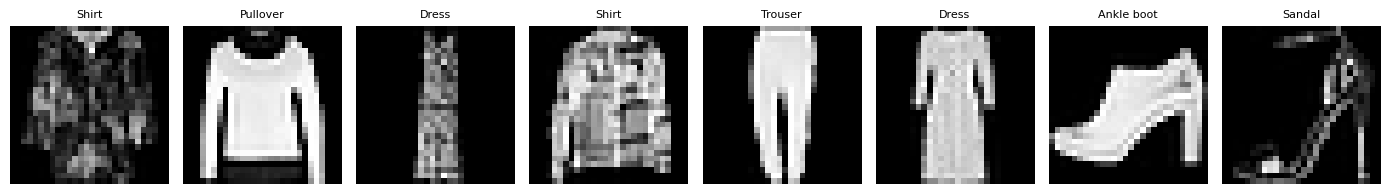

In [36]:
# Visualise a few samples
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(classes[labels[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()


## Step 2 — Define your model
Use `nn.Sequential` or a custom `nn.Module`. The input is a flattened 28×28 = 784-dim vector. The output should have 10 values (one per class).

In [37]:
# TODO: Define your classifier here.
#
# Requirements:
#   - Input:  784 (flattened 28x28 image)
#   - Output: 10  (one logit per class)
#   - At least one hidden layer with ReLU activation
#
# Hint: use nn.Flatten() as the first layer to go from (batch, 1, 28, 28) -> (batch, 784)
#
# YOUR CODE HERE

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
    )
print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


## Step 3 — Train the model

In [39]:
# TODO: Set up the loss function and optimizer.
# Use nn.CrossEntropyLoss() and torch.optim.Adam with lr=0.001
#
# YOUR CODE HERE

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [40]:
# TODO: Write the training loop.
# Train for 10 epochs.
# After each epoch, print: Epoch | Train Loss
# Store losses in a list so you can plot them later.
#
# Structure reminder:
#   for epoch in range(10):
#       for images, labels in train_loader:
#           images = images  (already batched)
#           ...
#
# YOUR CODE HERE
losses = []
for epoch in range(10):
    running_loss = 0
    for images, labels in train_loader:
        y_pred = model(images)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()        
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)
    print("Epoch", epoch + 1, "| Train Loss:", avg_loss)

Epoch 1 | Train Loss: 0.5036310744660495
Epoch 2 | Train Loss: 0.38186622442784846
Epoch 3 | Train Loss: 0.3426255346901381
Epoch 4 | Train Loss: 0.32014306577474577
Epoch 5 | Train Loss: 0.29956710750042503
Epoch 6 | Train Loss: 0.28525780493230707
Epoch 7 | Train Loss: 0.2728454771358321
Epoch 8 | Train Loss: 0.25986381104664763
Epoch 9 | Train Loss: 0.2505608718754894
Epoch 10 | Train Loss: 0.24195255110782982


## Step 4 — Plot the loss curve

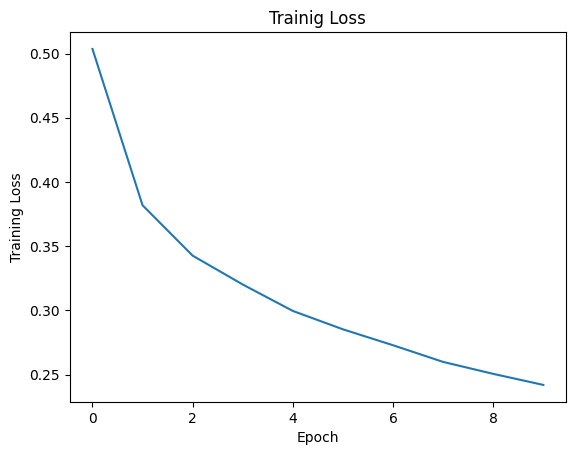

In [41]:
# TODO: Plot your training loss vs epoch.
# Label the axes and give the plot a title.
# YOUR CODE HERE
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Trainig Loss")
plt.show()


## Step 5 — Evaluate on the test set

In [42]:
# TODO: Compute accuracy on the test set.
# Loop over test_loader, count correct predictions, divide by total.
# Print the final accuracy as a percentage.
#
# Hint: use torch.no_grad() during evaluation — no need to compute gradients.
# Hint: predictions = logits.argmax(dim=1)
#
# YOUR CODE HERE
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += len(labels)
print("Accuracy:", (correct / total) * 100, "%")


Accuracy: 87.51 %


## Bonus (optional)
- Add a validation split (use 10% of training data)
- Plot both train and validation loss on the same graph
- Try adding `nn.Dropout(0.3)` and see if it helps
- Report: what happens if you increase the batch size to 256?

## Submission checklist
- [ ] Model defined with at least one hidden layer
- [ ] Training loop runs for 10 epochs without errors
- [ ] Loss curve plotted
- [ ] Test accuracy >= 85% printed
- [ ] Code is clean and all TODOs filled in